# Tomorrow's number

**Lecture 19 · Build** · Géron, Chapter 15

Applications of Machine Learning — BSc Mathematics of Artificial Intelligence

---

**How to use this notebook.** Read before you run. The cell marked **⚠ read before running** contains a defect on purpose, and it is the defect this application is about: it runs, it prints a believable number, and the number is better than the model can actually do.

**A CPU runtime is enough.** The largest model here has a few thousand parameters. If Colab offers you a GPU, decline it — for sequences this short the transfers cost more than the arithmetic saves.

**One number to commit to.** Before you fit anything you will write down a target. Everything after that is measured against it, including the parts that disappoint.

## 1 · Setup

Not examinable — engineering hygiene, kept out of the way of the argument.

**Every code cell below was generated, not typed.** The quoted block before each one is the exact prompt given to Colab's Gemini (3.1 Pro); the cell underneath is what came back, unedited. Read the prompt first and ask what it *fails* to say — in section 6 that question is the whole lecture.

> **Prompt · setup**
>
> Setup cell for a teaching notebook. Import numpy as np, pandas as pd, torch, torch.nn as nn and matplotlib.pyplot as plt. Set one seed, 42, for random, numpy and torch so the whole notebook is reproducible. Print the python, pandas and torch versions. Set matplotlib defaults once: figure size 11 by 3.2, grid on at alpha 0.3, font size 11. No comments explaining what an import is.

**Watch this prompt.** Every prompt box in this notebook is followed by three lines: what the prompt leaves open, the version a student actually writes, and how you would catch a wrong answer. They are the part worth reading twice.

* **Left open:** it asks for one seed but never says *where* it has to be set. A seed set after something has already drawn a random number is a seed that did nothing.
* **The usual student version:** "make it reproducible." That is a wish, not a specification — you get `np.random.seed(42)` on its own, and a torch model that still moves every run.
* **How you would catch it:** restart the runtime, run the whole notebook twice, and diff the printed numbers. Anything that moves is not seeded.

In [1]:
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"Torch version: {torch.__version__}")

plt.rcParams['figure.figsize'] = (11, 3.2)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

Python version: 3.12.13
Pandas version: 2.2.2
Torch version: 2.11.0+cpu


## 2 · The data

The Chicago Transit Authority publishes one row per day: how many people boarded a bus, how many boarded a train, and what kind of day it was. Twenty-one years of it.

> **Prompt · load the data**
>
> Load the Chicago Transit Authority daily boarding totals. The data is a tarball at `https://github.com/ageron/data/raw/main/ridership.tgz` which extracts to `datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv`. Download and extract it into a `datasets` folder only if it is not already on disk, so the notebook can be re-run offline. Parse `service_date` as a date. Call the result `raw` and print how many rows were published.

**Watch this prompt.**

* **Left open:** nothing about what to do if the download fails, and nothing that verifies the file is the one we meant. A truncated download becomes a short CSV, and a short CSV becomes a smaller MAE.
* **The usual student version:** dropping the words *only if it is not already on disk*. The notebook then re-downloads on every run, cannot be used offline, and quietly depends on GitHub being up during the exam.
* **How you would catch it:** run the cell twice. The second run should be instantaneous and print the same row count. If it stalls, the caching is not there.

In [2]:
import os
import tarfile
import urllib.request
import pandas as pd

url = "https://github.com/ageron/data/raw/main/ridership.tgz"
csv_path = "datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
tgz_path = "datasets/ridership.tgz"

if not os.path.exists(csv_path):
    os.makedirs("datasets", exist_ok=True)
    if not os.path.exists(tgz_path):
        urllib.request.urlretrieve(url, tgz_path)
    with tarfile.open(tgz_path) as tar:
        tar.extractall(path="datasets", filter="data")

raw = pd.read_csv(csv_path, parse_dates=["service_date"])
print(f"Published rows: {len(raw)}")

Published rows: 7701


### Tidying, and one line that matters

Four operations. Three are housekeeping and one is a decision:

* rename the columns, because `service_date` is long and we will type it often
* sort by date and index by it — a series with an unsorted index is a trap
* drop the column that carries no information
* **drop duplicate rows** — the published file repeats some days

Count the duplicates rather than assuming there are none. And notice what the prompt below does *not* say: it does not say which column to drop. That is deliberate. Check that the answer it picks is the right one, and that its reason is the right reason.

> **Prompt · tidy**
>
> Tidy `raw` into a frame called `df`. Rename the five columns to `date`, `day_type`, `bus`, `rail`, `total`. Sort by date and make date the index. One of these columns carries no information that the others do not already carry — work out which one and drop it. The published file repeats some days: remove the repeats and report how many there were. Print the date range that survives, and show the first three rows.

**Watch this prompt.**

* **Left open, on purpose:** which column to drop. Also, quietly: *"the file repeats some days"* never says whether a repeat means a repeated **row** or a repeated **date**. Those are different operations, and the code below picks one of them without saying so.
* **The usual student version:** "clean up the dataframe." You get a `dropna()` nobody asked for, an index silently reset, and no count of anything removed — so you cannot tell afterwards what the cleaning did.
* **How you would catch it:** do not take the explanation on trust; check the arithmetic. `(raw["total"] == raw["bus"] + raw["rail"]).all()` settles whether `total` really was redundant, in one line, without asking anyone.

In [3]:
df = raw.copy()
df.columns = ["date", "day_type", "bus", "rail", "total"]

# Count and remove duplicate days
num_duplicates = df.duplicated(subset=["date"]).sum()
df = df.drop_duplicates(subset=["date"])
print(f"Removed {num_duplicates} duplicate days.")

# Sort by date and set as index
df = df.sort_values("date").set_index("date")

# Drop the 'total' column as it is just the sum of 'bus' and 'rail'
df = df.drop(columns=["total"])

print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
display(df.head(3))

Removed 62 duplicate days.
Date range: 2001-01-01 to 2021-11-30


,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432


### 62 repeats — but the same day twice, or two different answers?

Read what it actually did: `drop_duplicates(subset=["date"])`. That keeps the **first** row for each date and throws the rest away. It is the right shape of operation — a daily series should have one row a day — but it quietly decides something the prompt never asked about.

If the 62 repeated dates carry *identical* numbers, nothing was lost. If any of them carry *different* numbers, then the notebook just picked one at random, on the basis of file order, and no later cell will ever mention it.

The difference is one line of code and it takes ten seconds. Not checking is how a data set acquires a decision nobody made.

> **Prompt · were the repeats consistent?**
>
> Before going on, check what those repeated dates were in `raw`. For each date appearing more than once, did the bus and rail figures agree across every copy? Report how many dates disagreed, and if any did, show one of them.

**Watch this prompt.** This one is deliberately tight, because it is a *check*. Checks are the one place where being vague costs you everything: a vague check reports something, you read a number, and you feel reassured about a question you never actually asked.

* **Left open:** almost nothing — and note how much longer it is than the prompt it is checking. That ratio is normal and it is not a sign you are doing something wrong.
* **The usual student mistake:** not writing this prompt at all. The previous cell printed a tidy number and a clean table; it *looked* finished. Nothing about a finished-looking output tells you which choices were made silently inside it.
* **How you would catch it:** you cannot, afterwards. That is the whole point. A silently-resolved ambiguity leaves no trace in any later cell — no warning, no exception, no odd-looking number. The only moment you can catch it is now.

In [4]:
dup_rows = raw[raw.duplicated(subset=["service_date"], keep=False)]

disagreed_dates = []
for date, group in dup_rows.groupby("service_date"):
    if group["bus"].nunique() > 1 or group["rail_boardings"].nunique() > 1:
        disagreed_dates.append(date)

print(f"Number of dates that disagreed: {len(disagreed_dates)}")

if disagreed_dates:
    example_date = disagreed_dates[0]
    print(f"\nExample of disagreement on {example_date.date() if hasattr(example_date, 'date') else example_date}:")
    display(raw[raw["service_date"] == example_date])

Number of dates that disagreed: 0


**Zero.** Every repeated date carried the same numbers in every copy, so keeping the first one threw nothing away and the tidy frame is sound.

That is the outcome you want, and it is worth being clear about why it was still worth asking. The check did not change a single number in this notebook. What it changed is that the sentence "there were 62 duplicate days and they were harmless" is now something we **know** rather than something we **assumed**. Had it come back non-zero, every result downstream would have rested on an arbitrary choice of row, and nothing further down would ever have complained.

The cost of the check was one prompt. The cost of skipping it is unbounded and silent. That asymmetry is most of this course.

From here on we work on `rail` alone.

## 3 · Look at it before you model it

Twenty-one years, then three months. Two time scales, two different facts, and neither one is visible at the other.

> **Prompt · the whole series**
>
> Plot the `rail` column of `df` against date, the whole twenty-one years, as a single line. Thin line, no markers — the shape is the point, not the individual days. Label the y axis and give the figure a title.

**Watch this prompt.**

* **Left open:** no units, no figure size, no colour. Harmless here because we fixed the defaults in section 1 — but only because we fixed them. A prompt that relies on state set three cells ago is a prompt that will not survive being copied somewhere else.
* **The usual student version:** "plot the data." With 7,639 points and default markers you get an unreadable black smear, and the one fact this figure exists to show — the March 2020 cliff — vanishes into it.
* **How you would catch it:** say out loud what single fact the figure is for, then look at whether that fact survived. If you cannot name the fact, you did not need the figure.

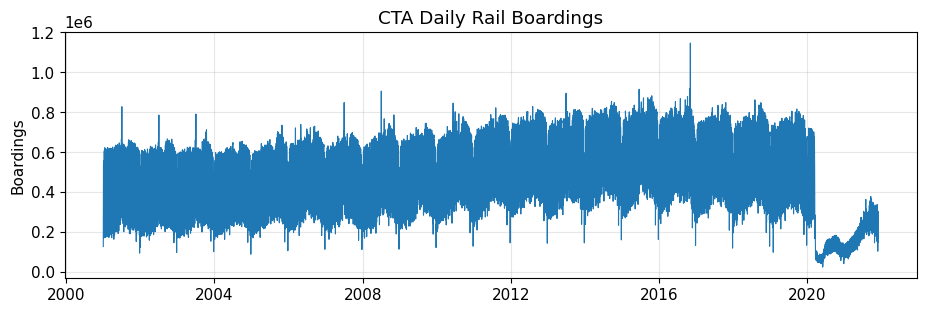

In [5]:
plt.plot(df.index, df['rail'], linewidth=0.8, marker='')
plt.title('CTA Daily Rail Boardings')
plt.ylabel('Boardings')
plt.show()

**What the plot says.** A slow decline through the 2010s, and then in March 2020 a cliff. Everything after that cliff is a different process, generated by a different world. We are not going to model across it: this notebook works on **2016-01 to 2019-05**, and Lecture 20 comes back to the cliff to ask what a model owes you when the world changes underneath it.

Now the other scale. Three months, both series, individual days visible.

> **Prompt · three months**
>
> Plot `bus` and `rail` together on one axis for March to May 2019 only. Use markers, since at this scale individual days matter. Label the axis and title it.

**Watch this prompt.**

* **Left open:** it names a date range but never says what the range is *for*. A window chosen because it makes the plot look tidy is a decision about evidence, and it should be made deliberately rather than by eye.
* **The usual student version:** plotting the whole series again and zooming with the mouse. That reads fine on your screen and is invisible to everyone else — the notebook, which is the thing you hand in, still shows the smear.
* **How you would catch it:** count. March to May 2019 is thirteen weeks, so there should be thirteen weekend troughs. If you cannot count them, the window is still too wide to support the claim you are about to make about weekly structure. (I first wrote *ten* here, and the figure is what caught it. That is the check working on its author.)

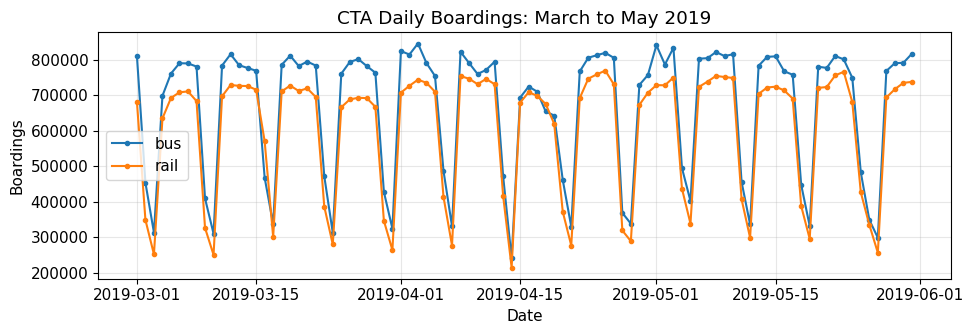

In [6]:
subset = df.loc['2019-03-01':'2019-05-31']

plt.plot(subset.index, subset['bus'], marker='.', label='bus')
plt.plot(subset.index, subset['rail'], marker='.', label='rail')
plt.title('CTA Daily Boardings: March to May 2019')
plt.ylabel('Boardings')
plt.xlabel('Date')
plt.legend()
plt.show()

**Weekly seasonality, and a second trough.** Every week has a deep weekend trough. Some weeks have a *third* dip in the middle of them, and those are the public holidays. A bare day-of-week feature would miss every one of them.

Whatever we build has to know what day of the week it is. The cheapest way to tell it is to show it the last week, or the last eight.

### The column that already knows

`day_type` takes three values: `W` for a weekday, `A` for a Saturday, `U` for a Sunday **or a public holiday**. That last word is the whole reason the column is worth having — the model cannot see a calendar, and the fourth of July behaves like a Sunday whatever the date says.

> **Prompt · day_type**
>
> Count how many days of each type there are in `df`. Then print the `day_type` values for 25 to 27 May 2019.

**Watch this prompt.**

* **Left open:** it does not say what those three days *should* come back as. Before you run it, decide: 25 May 2019 was a Saturday, 26 May a Sunday, 27 May was Memorial Day — a public holiday falling on a Monday. So you expect `A`, `U`, `U`. If you cannot state the expected answer first, you are not testing anything, you are printing.
* **The usual student version:** `value_counts()` and stop. That tells you the column exists and how the letters are distributed. It does not tell you what `U` *means*, which is the only thing you needed to know.
* **How you would catch it:** pick a date whose answer you already know from outside the data, and check that one. One well-chosen row is worth more than a summary table, because a summary table cannot be wrong in a way you would notice.

In [7]:
print("Day type counts:")
print(df['day_type'].value_counts())

print("\nDay types for 25 to 27 May 2019:")
print(df.loc['2019-05-25':'2019-05-27', 'day_type'])

Day type counts:
day_type
W    5336
U    1216
A    1087
Name: count, dtype: int64

Day types for 25 to 27 May 2019:
date
2019-05-25    A
2019-05-26    U
2019-05-27    U
Name: day_type, dtype: object


## 4 · Choose a metric, commit a number

Before a single model. Three candidates:

| Metric | What it says | Why not |
|---|---|---|
| **MAE** | average error in boardings | — |
| RMSE | punishes large errors more | one strike day dominates the score |
| MAPE | average error as a percentage | division by a small denominator |

**The MAPE trap.** MAPE divides by the truth. Christmas Day has about a tenth of a Tuesday's ridership, so a 20,000-boarding error on Christmas counts for as much as a 200,000-boarding error on a Tuesday. The metric would spend the model's capacity on the days nobody is planning staffing for.

We use **MAE, in boardings**. It is in the units the operations team already thinks in, and one unit of it is one person.

> **Prompt · the metric and the scoring window**
>
> Write a function `mae(truth, forecast)` returning the mean absolute error between two aligned series, in boardings. Days where either side is missing should not count. Then set `WINDOW = 56`, take the `rail` series from 2016-01 to 2019-05 as `pool`, and let `target` be the part of `pool` that a model using a 56-day window can actually be scored on. Print the length and date range of each.

**Watch this prompt.**

* **Left open:** "days where either side is missing should not count" says to drop them but not to *report* how many were dropped. A metric quietly averaged over three days is not comparable to one averaged over 1,191, and nothing in the printed number tells you which you got.
* **The usual student version:** `np.mean(np.abs(a - b))` on two pandas Series with different indexes. NumPy ignores the index and pairs by position; pandas aligns on it. The two give different answers, and neither one warns you.
* **How you would catch it:** `mae(x, x)` must be exactly `0`, and `mae(x, x.shift(1))` must not be. Two lines, and together they catch index misalignment the moment it appears rather than four cells later.

In [8]:
def mae(truth, forecast):
    return (truth - forecast).dropna().abs().mean()

WINDOW = 56
pool = df.loc['2016-01-01':'2019-05-31', 'rail']
target = pool.iloc[WINDOW:]

print(f"Pool length: {len(pool)}, Date range: {pool.index.min().date()} to {pool.index.max().date()}")
print(f"Target length: {len(target)}, Date range: {target.index.min().date()} to {target.index.max().date()}")

Pool length: 1247, Date range: 2016-01-01 to 2019-05-31
Target length: 1191, Date range: 2016-02-26 to 2019-05-31


**1,247 days in the pool, 1,191 of them scorable.** The 56 that disappear are the first window — no model can forecast a day it has no history for. `target` begins 2016-02-26, which is 56 days after 2016-01-01. Do that subtraction yourself rather than believing this sentence.

And notice that the prediction in the box above came true. **Left open** said the prompt asks for missing days to be dropped but never asks how many were dropped — and look at what came back: `.dropna()`, no count. Harmless here, because we already know there are no gaps. But we know that because we checked in section 2, not because this cell told us.

So let us do the two-line check the annotation asked for, and get the count while we are there.

> **Prompt · test the metric before trusting it**
>
> Verify `mae`: it must return exactly 0 for `target` against itself, and something clearly non-zero for `target` against a copy of itself shifted by one day. For each of the two cases also report how many days the mean was actually taken over.

**Watch this prompt.**

* **Left open:** it does not say what "clearly non-zero" is. That is fine for a smoke test and would not be fine for an assertion — know which of the two you are writing. A test that passes for any number above zero is a test that will still pass when the metric is broken.
* **The usual student version:** skipping this cell entirely because `mae` is four lines long and obviously correct. Index alignment bugs do not care how short your function is; they care whether the two things you subtract are indexed the same way, and that is invisible in four lines of source.
* **How you would catch it:** the shifted case is the load-bearing one. `mae(x, x) == 0` passes even for a function that always returns zero. Only the second case can tell those apart — which is why a test needs a case it is *supposed* to fail.

In [9]:
mae_same = mae(target, target)
count_same = (target - target).dropna().count()
print(f"MAE (target vs target): {mae_same} over {count_same} days")

shifted = target.shift(1)
mae_shifted = mae(target, shifted)
count_shifted = (target - shifted).dropna().count()
print(f"MAE (target vs shifted): {mae_shifted:.2f} over {count_shifted} days")

MAE (target vs target): 0.0 over 1191 days
MAE (target vs shifted): 130844.66 over 1190 days


**Both cases pass, and the day counts are the interesting part.** 1,191 days against itself, 1,190 against the shifted copy — the shift costs exactly one day, which is what a one-day shift should cost. Had those two counts been equal, or had the second been 1,135, something would be wrong with the alignment and the MAE would still have printed a perfectly plausible number.

### The baselines

A number is only good or bad next to another number. Here are four forecasts that require no fitting at all.

> **Prompt · baselines**
>
> Score four forecasts that need no fitting, against `target`, using `mae`: (1) a constant equal to the mean of `pool` up to the end of 2018; (2) copy the value from the day before; (3) copy the value from the same day one week earlier; (4) copy from two weeks earlier. Print each one's MAE, and print how many days each was scored on.

**Watch this prompt.**

* **Left open:** it asks for the day counts but does not say they must be *equal*. They must be, or the four numbers are not comparable — and four numbers in a tidy column look comparable whether or not they are. Printing the count makes the flaw visible; requiring it to match would make the flaw impossible.
* **The usual student version:** comparing against the mean, or against zero, and stopping there. Both are trivially beatable. The number that matters is the cheapest thing a competent person would do *without* you, and here that is copying last week.
* **How you would catch it:** copying **last week** must beat copying **yesterday**, and by a wide margin — ridership is far more like the same weekday than like the previous day. If yesterday wins, you have shifted the wrong way or by the wrong number of days. This check works because it predicts a specific ordering, not merely "a number appears".

In [10]:
mean_2018 = pool.loc[:'2018-12-31'].mean()
baseline_constant = pd.Series(mean_2018, index=target.index)
baseline_yesterday = pool.shift(1).loc[target.index]
baseline_last_week = pool.shift(7).loc[target.index]
baseline_two_weeks = pool.shift(14).loc[target.index]

baselines = {
    "Mean up to 2018": baseline_constant,
    "Yesterday": baseline_yesterday,
    "Last week": baseline_last_week,
    "Two weeks ago": baseline_two_weeks
}

for name, forecast in baselines.items():
    mae_val = mae(target, forecast)
    count = (target - forecast).dropna().count()
    print(f"{name:20s} MAE: {mae_val:,.2f} over {count} days")

Mean up to 2018      MAE: 159,566.13 over 1191 days
Yesterday            MAE: 130,745.60 over 1191 days
Last week            MAE: 55,398.56 over 1191 days
Two weeks ago        MAE: 61,211.70 over 1191 days


**Read that table before going on.** Copying the same weekday one week ago scores 55,399. Copying yesterday scores 130,746 — **2.4 times worse**. The mean scores 159,566, nearly three times worse. All four on the same 1,191 days, so the comparison is real.

The check in the box above predicted exactly this ordering, and it held. Had it not, we would have a shift bug rather than a finding.

So: copying last week costs nothing, has no parameters, cannot overfit, and already knows about weekends and — by accident, through `day_type`'s holidays being ordinary low days — about most public holidays too. **That is the number to beat.** Not the mean. Not zero.

### ★ Commit

Write the target down now, before you have seen a single model's score. It is much harder to call a result disappointing after you already know what it is.

> **Prompt · commit a target**
>
> Set `NAIVE_MAE` to the MAE of copying last week. Choose an improvement over it that would be worth deploying, put that fraction in a clearly-named constant, and compute `TARGET_MAE` from the two. Print both numbers and the percentage. Make the constant easy to find and hard to edit by accident later.

**Watch this prompt.**

* **Left open:** what the improvement should *be*. Deliberately — nobody can tell you that from the data, it comes from what the forecast is for. Ten per cent of 55,399 is about 5,500 boardings a day; decide whether a staffing decision would change over that before you pick the number.
* **The usual student version:** never writing this cell. You fit a model, get 51,000, and decide afterwards that 8% is a good result — which it might be, but you can no longer tell, because the standard was chosen by the answer. This is the single most common way an honest person reports a dishonest result.
* **How you would catch it:** you cannot catch it later, only prevent it now. The test is whether the number is written **above** the model in the notebook, not below it. Scroll position is the evidence.

In [11]:
NAIVE_MAE = mae(target, baseline_last_week)
TARGET_IMPROVEMENT_FRACTION = 0.10  # 10% improvement
TARGET_MAE = NAIVE_MAE * (1 - TARGET_IMPROVEMENT_FRACTION)

print(f"Naive MAE (Last week): {NAIVE_MAE:,.2f}")
print(f"Target Improvement:    {TARGET_IMPROVEMENT_FRACTION * 100:.1f}%")
print(f"Target MAE:            {TARGET_MAE:,.2f}")

Naive MAE (Last week): 55,398.56
Target Improvement:    10.0%
Target MAE:            49,858.70


## 5 · Turning a series into a table

Supervised learning wants rows. A series is not rows, so we cut it into overlapping windows: 56 days in, the 57th day out.

Why 56? Eight whole weeks. Any multiple of seven lets a model line up the same weekday; eight of them give it enough repetitions to average over. And why divide by a million — because the numbers are around 600,000, and a network initialised in the usual way expects inputs near 1.

> **Prompt · the windowing dataset**
>
> Write a `torch.utils.data.Dataset` called `TimeSeriesDataset` taking a series and a window length. Item `i` is the window starting at `i` together with the value that comes immediately after that window. Its length should be whatever number of such pairs exist.

**Watch this prompt.**

* **Left open:** "the value that comes immediately after" is one word away from "the last value in the window". An off-by-one here leaks exactly one day of the future into every training row, the model gets suspiciously good, and **nothing raises an error** — the shapes are identical either way.
* **The usual student version:** `return self.series[i:i+w], self.series[i+w-1]`, or a `__len__` of `len(series)`. The second one throws an `IndexError` on the final item, which is the lucky case, because at least you find out.
* **How you would catch it:** never by reading it. Run the class on six integers and a window of three, print every pair, and confirm by eye that the target is never inside its own window. That is the next cell, and it exists because reading is not sufficient here.

In [12]:
import torch
from torch.utils.data import Dataset
import pandas as pd

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_length):
        # Convert to tensor cleanly whether it's a pandas Series, list, or already a tensor
        if isinstance(series, pd.Series):
            self.series = torch.tensor(series.values, dtype=torch.float32)
        elif isinstance(series, torch.Tensor):
            self.series = series.clone().detach().to(torch.float32)
        else:
            self.series = torch.tensor(series, dtype=torch.float32)
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, i):
        window = self.series[i : i + self.window_length]
        target = self.series[i + self.window_length]
        return window, target

### Test the class before trusting it

Six numbers, a window of three. Read the output and confirm by eye that the target is the step *after* the window and never inside it.

> **Prompt · the six-number test**
>
> Build a `TimeSeriesDataset` over the integers 0 to 5 with a window length of 3, and print every window next to the value that follows it. Print how many pairs there were.

**Watch this prompt.**

* **Left open:** it says print, not assert. On six numbers printing is right — you are checking your *understanding* of the contract, and an assertion checks a value you have already understood. Once you believe the contract, convert to assertions; the next cell does exactly that.
* **The usual student version:** testing on the real 1,247-day series. Nothing is checkable there. The whole value of six integers is that you can hold the right answer in your head and compare.
* **How you would catch it:** you should see exactly **3** pairs — `[0,1,2]→3`, `[1,2,3]→4`, `[2,3,4]→5`. Six values minus a window of three. If you see 4 pairs, `__len__` is wrong; if the last number of a window equals its own target, `__getitem__` is off by one.

In [13]:
test_series = list(range(6))
test_ds = TimeSeriesDataset(test_series, window_length=3)

for i in range(len(test_ds)):
    window, target = test_ds[i]
    print(f"{window.tolist()} -> {target.item()}")

print(f"\nTotal pairs: {len(test_ds)}")

[0.0, 1.0, 2.0] -> 3.0
[1.0, 2.0, 3.0] -> 4.0
[2.0, 3.0, 4.0] -> 5.0

Total pairs: 3


**Three pairs, and every target sits outside its own window.** The contract holds. Now the same class on the real series.

> **Prompt · build the tensors**
>
> Scale the `pool` values by dividing by a million and make a float32 tensor of shape (days, 1). Run `TimeSeriesDataset` over it with `WINDOW`, then stack every window into `X` and every target into `y`. Assert the shapes rather than printing them, so a wrong shape stops the notebook here instead of surfacing as a strange score later. Print the shapes once the assertions pass.

**Watch this prompt.**

* **Left open:** why a million. It says to divide but not why, and a constant with no reason attached is a constant nobody will dare change. The reason is that ridership is around 600,000 and network initialisation assumes inputs near 1 — so `1e6` is a scale choice, not a magic number.
* **The usual student version:** `print(X.shape)` instead of asserting. A printed shape is only a check if a human reads it, and by cell 30 nobody is reading. An assertion is a check that still works when you are tired.
* **How you would catch it:** you should get `X` of shape **(1191, 56, 1)** and `y` of **(1191, 1)** — 1,247 days minus the 56-day first window, which is the same 1,191 the baselines were scored on. If those two numbers ever stop matching, the model and the baselines are being judged on different days and the comparison is void.

In [14]:
pool_tensor = torch.tensor((pool / 1e6).values, dtype=torch.float32).unsqueeze(-1)
ds = TimeSeriesDataset(pool_tensor, window_length=WINDOW)

X = torch.stack([ds[i][0] for i in range(len(ds))])
y = torch.stack([ds[i][1] for i in range(len(ds))])

expected_length = len(pool) - WINDOW
assert X.shape == (expected_length, WINDOW, 1), f"X shape is wrong: {X.shape}"
assert y.shape == (expected_length, 1), f"y shape is wrong: {y.shape}"

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: torch.Size([1191, 56, 1])
y shape: torch.Size([1191, 1])


## 6 · ⚠ Read before running

This is the cell the whole application is about.

What we want is simple: *score a linear model on 56 lags.* The prompt below is what a competent, careful person actually types when they want that. It is not lazy. It asks for reproducibility, for per-fold numbers, for a comparison against the baseline — all the things you have been taught to ask for.

**It runs. It prints a believable number. The number is wrong.**

Read the prompt, then read the code, and only then run it.

> **Prompt · a cross-validated linear model**
>
> Fit a `LinearRegression` on the 56 lags. Flatten `X` to (rows, 56) and `y` to a vector. Report a 5-fold cross-validated MAE in boardings, with a fixed random seed so the number is reproducible, and print the per-fold values as well as the mean. Print `NAIVE_MAE` next to it for comparison.

**Watch this prompt.** This one is different from the others. Do not skip to the next cell.

* **Left open:** the prompt never once mentions that these rows are **days, in order**. It describes `X` as a table of 1,191 rows and 56 columns, which is true, and says nothing about what the rows *are*. Every other constraint it asks for is about reproducibility, not about validity.
* **The usual student version:** this *is* the usual student version. That is the point of the cell. There is no sloppier variant to warn you about — the failure below is what you get from a careful prompt with one unstated assumption.
* **How you would catch it:** not from this cell. Its five folds will agree with each other, its standard deviation will be small, and it will beat the baseline by a comfortable margin. Every signal you would normally reach for will say the number is fine. Write the number down anyway, then run the cell after it.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Flatten X to (rows, 56) and y to a vector
X_flat = X.view(X.shape[0], -1).numpy()
y_flat = y.view(-1).numpy()

# Set up 5-fold cross-validation with a fixed random seed
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# Compute cross-validated negative mean absolute error
scores = cross_val_score(model, X_flat, y_flat, cv=kf, scoring='neg_mean_absolute_error')

# Convert negative scaled scores back to positive boardings
mae_folds = -scores * 1e6
mean_mae = mae_folds.mean()

# Print the per-fold values
print("Per-fold MAE:")
for i, fold_mae in enumerate(mae_folds):
    print(f"  Fold {i+1}: {fold_mae:,.2f}")

# Print the mean and the naive baseline for comparison
print(f"\nMean CV MAE: {mean_mae:,.2f}")
print(f"NAIVE_MAE:   {NAIVE_MAE:,.2f}")

Per-fold MAE:
  Fold 1: 51,096.16
  Fold 2: 43,677.87
  Fold 3: 39,537.77
  Fold 4: 43,737.64
  Fold 5: 45,754.40

Mean CV MAE: 44,760.77
NAIVE_MAE:   55,398.56


### Why that number was so easy to believe

**44,761 against a naive 55,399.** A 19% improvement, comfortably past the 49,859 we committed to in section 4. And look at the folds: 51,096 / 43,678 / 39,538 / 43,738 / 45,754. They agree with each other. There is no outlier, no fold that fell over, nothing that asks for a second look.

Every instinct you have been trained to use says this result is sound. That is precisely why it is the defect worth an entire lecture.

**Now look at what `shuffle=True` does to a series.** Held-out day *t* has days *t−1* and *t+1* sitting in the training set. Yesterday's ridership predicts today's extremely well. So the model is not forecasting at all — it is **interpolating between two days it has already seen**. Nothing you deploy will ever have that. Tomorrow does not come with the day after tomorrow attached.

The five folds agreed because they were all wrong in the same way. **A stable measurement of the wrong quantity is stable.**

Score it the way it will actually be used — train on the past, predict the future — and the same model on the same data gives a different number.

> **Prompt · score it the way it will be used**
>
> Fit the same `LinearRegression` on the same `X_flat` and `y_flat`, but split by position instead of at random: the first 80% of rows for training, the last 20% for testing, with no shuffling anywhere. Report the test MAE in boardings. Print it beside the shuffled cross-validated number and state the gap in boardings and as a percentage. Keep the fitted model in a variable so later cells can inspect its coefficients.

**Watch this prompt.**

* **Left open:** "the first 80%" assumes the rows are already in date order. They are, because `TimeSeriesDataset` walked the series forwards — but the prompt does not verify it, and a single `sort` or `sample` anywhere upstream would silently break the guarantee while the code kept running.
* **The usual student version:** `train_test_split(X, y, test_size=0.2)`. That function shuffles **by default**. It is the single most common way this exact defect survives a supposed fix — the person believes they have split by time and has in fact reshuffled.
* **How you would catch it:** the honest number must be **worse**. If a time split ever comes out *better* than a shuffled one on a series with strong day-to-day correlation, you have not fixed the leak — you have moved it. Expect the gap, and be suspicious when it does not appear.

In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Calculate the row index for the 80% split
split_index = int(len(X_flat) * 0.8)

# Split X_flat and y_flat by position
X_train, X_test = X_flat[:split_index], X_flat[split_index:]
y_train, y_test = y_flat[:split_index], y_flat[split_index:]

# Fit a LinearRegression model on the training split
model_time_split = LinearRegression()
model_time_split.fit(X_train, y_train)

# Predict on the test split and compute the mean absolute error in boardings
predictions = model_time_split.predict(X_test)
test_mae = np.mean(np.abs(y_test - predictions)) * 1e6

# Calculate the gap between the test MAE and the shuffled mean CV MAE
gap_boardings = test_mae - mean_mae
gap_percentage = (gap_boardings / mean_mae) * 100

# Print the metrics
print(f"Time-split Test MAE: {test_mae:,.2f}")
print(f"Shuffled CV MAE:     {mean_mae:,.2f}")
print(f"Gap in boardings:    {gap_boardings:,.2f}")
print(f"Gap as percentage:   {gap_percentage:.1f}%")

Time-split Test MAE: 52,450.70
Shuffled CV MAE:     44,760.77
Gap in boardings:    7,689.93
Gap as percentage:   17.2%


### The same model, the same data, two different answers

| | MAE | vs naive |
|---|---|---|
| random 5-fold, shuffled | 44,761 | 19.2% better |
| **train on the past, predict the future** | **52,451** | **5.3% better** |
| copy last week (no fitting) | 55,399 | — |
| **committed target (§4)** | **49,859** | 10% better |

**The split flattered the model by 7,690 boardings — 17.2%.** Nothing else changed. Same rows, same columns, same estimator, same seed. Only the question changed: *can it interpolate between days it has seen* versus *can it forecast a day it has not*.

And now look at the last two rows together, because this is what section 4 was for.

Against the shuffled number, the model **beat** its target and you would have shipped it. Against the honest number, it **misses** — 52,451 against a target of 49,859. Five per cent better than copying last week, for a linear model on 56 lags, a scaler, and a pipeline someone has to maintain.

If you had chosen the target *after* seeing 44,761, you would have chosen something the model passes. That is why the number was written down first. **The commitment is not bureaucracy; it is the only part of this notebook that could have stopped you.**

Keep both numbers. Lecture 20 takes the honest one apart and finds that it is still not honest enough — an 80/20 cut by time is better than a shuffle, but we still compared two models on the same test set, and that is a selection we have not paid for.

### A note on what just happened here

The first time this cell was generated, the assistant added a comment to its own code reading *"this introduces the shuffling trap"* — because it could see the markdown above saying the number would be wrong. It had to be asked again, with the surrounding commentary suppressed, before it produced the defect without flagging it.

That is worth knowing in both directions. An assistant that can see your doubts will often share them. An assistant that cannot — because you never wrote them down — will hand you `shuffle=True` and a congratulatory summary. **The difference was not the model's capability. It was whether the context contained anybody's suspicion.**

## 7 · What the linear model learned

56 lags in, one number out — 57 parameters. Plot the coefficient on each lag against the lag, and the model tells you what it found, in a language you can go and check against the data.

> **Prompt · coefficients against lag**
>
> Plot the 56 coefficients of the time-split linear model against lag, with lag 1 on the right so the axis reads as time running backwards from today. Mark the whole weeks with vertical lines. Then print the mean coefficient on lags 7, 14, 21 and 28 against the mean coefficient on all the other lags.

**Watch this prompt.**

* **Left open:** it does not say what the figure is supposed to *show*, so there is no way for it to fail. Decide before you run it: if the model has found the weekly structure by itself, weight should pile up on multiples of seven. Now the plot can disappoint you, which is the only way a plot can be useful.
* **The usual student version:** plotting the coefficients without inverting the axis, so lag 56 sits on the left and lag 1 on the right of a *forwards*-reading axis — the picture is then a mirror image of time and every sentence you write about it is backwards.
* **How you would catch it:** do not eyeball 56 bars. The printed comparison is the actual check; the figure is only an illustration of it. Fifty-six bars is comfortably enough for a person to see a pattern that is not there, which is why the number goes underneath.

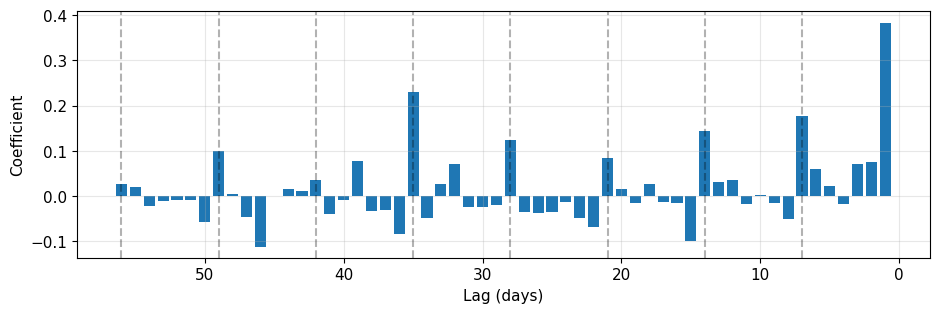

Mean coefficient on lags 7, 14, 21, 28: 0.1325
Mean coefficient on all other lags:     0.0059


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the 56 coefficients from the fitted time-split model
coefficients = model_time_split.coef_.flatten()

# Create an array of lag numbers from 56 down to 1
lags = np.arange(56, 0, -1)

# Plot the coefficients as a bar chart against the lag numbers
plt.bar(lags, coefficients)

# Invert the x-axis to place lag 1 on the right
plt.gca().invert_xaxis()

# Draw vertical lines at multiples of 7
for week in range(1, 9):
    plt.axvline(x=week*7, color='black', linestyle='--', alpha=0.3)

# Label the axes and display the figure
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.show()

# Calculate the zero-based array indices for lags 7, 14, 21, and 28
weekly_lags = [7, 14, 21, 28]
weekly_indices = [56 - lag for lag in weekly_lags]

# Calculate the indices for the remaining 52 lags
other_indices = [i for i in range(56) if i not in weekly_indices]

# Compute the mean coefficient for both sets of indices
mean_weekly = np.mean(coefficients[weekly_indices])
mean_other = np.mean(coefficients[other_indices])

# Print the computed means
print(f"Mean coefficient on lags 7, 14, 21, 28: {mean_weekly:.4f}")
print(f"Mean coefficient on all other lags:     {mean_other:.4f}")

**0.1325 against 0.0059.** The weekly lags carry twenty-two times the weight of all the others put together. Nobody told this model about weeks; it found them because they are in the data. Look at the figure and you can see the spikes standing on the dashed lines at 7, 14, 21, 28 — and the tallest bar of all at lag 1, yesterday.

This is the pleasant version of a linear model being interpretable: the coefficients make a claim about the world, and the claim is one you can go and check.

## 8 · A recurrent network

The linear model treats lag 3 and lag 45 as two unrelated columns. A recurrent layer instead reads the window one step at a time, carrying a hidden state:

$$\mathbf{h}_t = \tanh(W_x \mathbf{x}_t + W_h \mathbf{h}_{t-1} + \mathbf{b})$$

The same weights at every step. That is the parameter saving, and it is also the assumption: *what a value means does not depend on where in the window it sits.*

> **Prompt · the model**
>
> Write an `nn.Module` called `SimpleRnn` that takes a batch of windows shaped [batch, time, series] and returns one number per window. Use `nn.RNN` with 32 hidden units and `batch_first`, and put a linear layer on the final time step. Print the parameter count, split between the recurrent part and the head.

**Watch this prompt.**

* **Left open:** *why* there has to be a linear head. `nn.RNN` hands you a hidden state squashed into [−1, 1] by the tanh, and ridership is not in [−1, 1] — the head is what turns a state into a quantity. Leaving it out is the most common way this model is got wrong, and it fails quietly: the loss goes down, the predictions saturate.
* **The usual student version:** returning `outputs` rather than `outputs[:, -1]`. You then get one prediction per *timestep* instead of one per window, the shapes still broadcast against `y`, and the loss is an average over 56 predictions of which 55 are meaningless.
* **How you would catch it:** the parameter count. 1 input × 32 hidden + 32 × 32 recurrent + 2 × 32 bias = 1,120 in the RNN, and 32 × 1 + 1 = 33 in the head. If the head has no parameters, you forgot it. Arithmetic you can do on paper beats a shape you glanced at.

In [18]:
import torch
import torch.nn as nn

class SimpleRnn(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize an RNN layer with 1 input feature and 32 hidden units
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        # Initialize a linear layer with 32 input features and 1 output feature
        self.head = nn.Linear(in_features=32, out_features=1)

    def forward(self, x):
        # Pass the input batch through the RNN
        outputs, hidden = self.rnn(x)
        # Extract the output at the final time step for all items in the batch
        last_output = outputs[:, -1, :]
        # Pass the extracted final step through the linear layer
        return self.head(last_output)

# Create an instance of the model
model = SimpleRnn()

# Sum the elements in the RNN parameters
rnn_params = sum(p.numel() for p in model.rnn.parameters())

# Sum the elements in the head parameters
head_params = sum(p.numel() for p in model.head.parameters())

# Print the parameter counts
print(f"RNN parameters:  {rnn_params}")
print(f"Head parameters: {head_params}")
print(f"Total:           {rnn_params + head_params}")

RNN parameters:  1120
Head parameters: 33
Total:           1153


**1,120 recurrent, 33 in the head, 1,153 in total** — exactly the arithmetic above. The head exists and has parameters.

### The training loop

Three choices worth stating out loud:

* **Huber loss** with δ = 0.05. Since we scaled by a million, that is 50,000 boardings: quadratic below it, linear above. A strike day steers the fit far less than it would under MSE.
* **Shuffle the windows.** The *series* must never be shuffled; the *windows* must be, or every batch is one contiguous stretch of days and the gradients within a batch are correlated.
* **The same time split.** The same 80/20 cut as the linear model, so the two are comparable.

> **Prompt · train it**
>
> Train `SimpleRnn` on the same 80/20 split by position that the linear model used. Huber loss with delta 0.05, SGD at learning rate 0.05 with momentum 0.9, batches of 32, 200 epochs, batches shuffled. Every 20 epochs print the held-out MAE in boardings.

**Watch this prompt.**

* **Left open:** "batches shuffled" is ambiguous between shuffling the **windows** and shuffling the **series**. Shuffling the windows is required; shuffling the series would destroy the data outright. A `DataLoader` can only do the first, so the ambiguity is harmless *here* — but you should know which one you meant, because the phrasing would be equally natural in a place where it is not harmless.
* **The usual student version:** printing only the final score. You then cannot distinguish a model that converged from one that was still improving, or from one that peaked at epoch 60 and has been getting worse since.
* **How you would catch it:** the held-out MAE should fall and then flatten. If it *rises*, say so — do not quietly report the best epoch you saw. Choosing an epoch by its test score is a selection made on the test set, and it is the same class of error as the shuffle above, only smaller.

In [19]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Split tensors by position
split_idx = int(len(X) * 0.8)
X_train_t, X_test_t = X[:split_idx], X[split_idx:]
y_train_t, y_test_t = y[:split_idx], y[split_idx:]

# Create a DataLoader for the training set with shuffled batches
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize the loss function and optimizer
criterion = nn.HuberLoss(delta=0.05)
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

# Loop over the dataset 200 times
for epoch in range(1, 201):
    model.train()
    for batch_X, batch_y in train_loader:
        # Clear previous gradients
        optimizer.zero_grad()
        # Compute predictions and loss
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        # Compute gradients and update weights
        loss.backward()
        optimizer.step()

    # Evaluate on the held-out split every 20 epochs
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_t)
            # Calculate MAE and scale back to boardings
            test_mae = (test_preds - y_test_t).abs().mean().item() * 1e6
        print(f"Epoch {epoch:3d} | Held-out MAE: {test_mae:,.2f}")

Epoch  20 | Held-out MAE: 133,842.08
Epoch  40 | Held-out MAE: 80,356.61
Epoch  60 | Held-out MAE: 65,723.23
Epoch  80 | Held-out MAE: 51,887.52
Epoch 100 | Held-out MAE: 50,566.57
Epoch 120 | Held-out MAE: 47,411.37
Epoch 140 | Held-out MAE: 44,316.50
Epoch 160 | Held-out MAE: 52,307.17
Epoch 180 | Held-out MAE: 49,127.35
Epoch 200 | Held-out MAE: 48,964.94


### It did not flatten. Read it anyway.

Look at what the held-out MAE actually did:

```
 20  133,842      100   50,567
  40   80,357      120   47,411
   60   65,723      140   44,317   <- lowest
    80   51,888      160   52,307   <- rises
                      180   49,127
                                        200   48,965
                                        ```

                                        It fell steeply, reached **44,317 at epoch 140**, and then went **back up**. The annotation above said: *if it rises, say so — do not quietly report the best epoch you saw.* So: it rose.

                                        **44,317 is not this model's score.** It is the lowest of ten numbers we looked at on the test set, and picking it would mean choosing an epoch *because* of its test performance — which is a selection made on the test set, exactly the family of error section 6 was about, only smaller and much easier to excuse. The number we are entitled to report is the one at the epoch we said we would stop at: **48,965**.

                                        Notice also how much the last four readings move: 44,317, 52,307, 49,127, 48,965. That spread is about 8,000 boardings. Hold that thought until the red-team exercise at the end.

                                        > **Prompt · the final table**
                                        >
                                        > Print one table comparing three forecasts on the held-out period: copying last week, the time-split linear model, and the trained RNN at its final epoch. For each give the MAE and the percentage improvement over `NAIVE_MAE`. Underneath, print `TARGET_MAE` and say plainly whether each model met it.

                                        **Watch this prompt.**

                                        * **Left open:** which RNN score to use. The prompt says *at its final epoch*, and it says so because leaving that open is how 44,317 ends up in the table. When a number could be selected several ways, the prompt is where you fix the choice — not the reader's judgement afterwards.
                                        * **The usual student version:** a table of the models only, with the baseline in the prose above it and the target nowhere at all. The reader then compares the models with each other, which is the one comparison that cannot tell you whether any of them is worth deploying.
                                        * **How you would catch it:** the committed number must appear **in the table**, next to the results, whether or not they beat it. If you find yourself wanting to leave it out, that is the strongest possible evidence that it belongs there.

In [20]:
import numpy as np
import torch

# Recreate the target series since the 'target' variable was overwritten by a loop earlier
target_series = pool.iloc[WINDOW:]

# Calculate MAE for the naive baseline on the held-out period
test_target = target_series.iloc[split_idx:]
test_baseline = baseline_last_week.iloc[split_idx:]
baseline_held_out_mae = (test_target - test_baseline).abs().mean()

# Calculate MAE for the linear model on the test split
linear_predictions = model_time_split.predict(X_test)
linear_held_out_mae = np.mean(np.abs(y_test - linear_predictions)) * 1e6

# Calculate MAE for the RNN on the test split
model.eval()
with torch.no_grad():
    rnn_predictions = model(X_test_t)
    rnn_held_out_mae = (rnn_predictions - y_test_t).abs().mean().item() * 1e6

# Create a list of tuples containing model names and their MAEs
models = [
    ("Copying last week", baseline_held_out_mae),
    ("Linear (time split)", linear_held_out_mae),
    ("RNN (final epoch)", rnn_held_out_mae)
]

# Print the table header
print(f"{'Model':<22} | {'MAE':<10} | {'Improvement vs NAIVE_MAE'}")
print("-" * 63)

# Loop through the list to print each model's row
for name, model_mae in models:
    # Calculate the percentage improvement relative to NAIVE_MAE
    improvement = ((NAIVE_MAE - model_mae) / NAIVE_MAE) * 100
    # Print the formatted string
    print(f"{name:<22} | {model_mae:10,.0f} | {improvement:6.1f}%")

# Print an empty line and the TARGET_MAE
print(f"\nTARGET_MAE: {TARGET_MAE:,.0f}\n")

# Loop through the list to print whether each model met the target
for name, model_mae in models:
    # Determine if the MAE is less than or equal to TARGET_MAE
    met = "Yes" if model_mae <= TARGET_MAE else "No"
    # Print the outcome
    print(f"{name} met target: {met}")

Model                  | MAE        | Improvement vs NAIVE_MAE
---------------------------------------------------------------
Copying last week      |     67,225 |  -21.3%
Linear (time split)    |     52,451 |    5.3%
RNN (final epoch)      |     48,965 |   11.6%

TARGET_MAE: 49,859

Copying last week met target: No
Linear (time split) met target: No
RNN (final epoch) met target: Yes


## 9 · Where we finish — and the number in this table that is wrong

The RNN met the committed target and the linear model did not. That is the headline, and you should not trust it yet, because **there is a defect in the table above and it is mine, not the assistant's.**

Look at the first row. Copying last week scores **67,225** here. In section 4 the same forecast scored **55,399**. Same forecast, same data, same metric — different number, because section 4 scored it over all 1,191 days and this table scores it over the last 20% only.

**The final quarter of this period is simply harder to forecast.** The naive baseline is 21% worse there than on average. So the `Improvement vs NAIVE_MAE` column compares models measured on the *hard* window against a baseline measured on the *whole* window. That is not a like-for-like comparison, and it makes the models look worse than they are.

Scored against the baseline **on the same days they were**:

| | MAE on held-out | vs naive on held-out |
|---|---|---|
| copy last week | 67,225 | — |
| linear, time split | 52,451 | **22.0% better** |
| RNN, final epoch | 48,965 | **27.2% better** |

Both models beat the naive forecast by far more than the table said. And the committed target inherits the same flaw: 49,859 was 10% below a baseline of 55,399. Taken on the held-out window, a 10% improvement on 67,225 would be 60,502 — which **both** models clear easily.

So which is right? The second table. A model and its baseline must be scored on the same days, and §4 fixed the target before the split existed. **Committing to a number early was still correct; committing to a number whose baseline you had not yet pinned down was the mistake.** Lecture 20 begins here.

### The other thing that broke

This cell failed the first time with an `AttributeError`. The cause: `target` — the pandas Series of scored days defined in section 4 — had been silently overwritten ten cells earlier, by the loop variable in the six-number toy test:

```python
for window, target in TimeSeriesDataset(toy, 3):   # <- rebinds `target`
```

A throwaway loop variable in a *test* clobbered a name the rest of the notebook depended on. Nothing complained for ten cells. It only surfaced because the last cell happened to touch the old name again — and had it not, the notebook would have finished cleanly with no indication that anything was wrong.

Notebook state is global and mutable, and cells can be run in any order. That is not a Colab quirk; it is the execution model, and it is why this course keeps asking you to re-run from the top before believing anything.

### ★ Record your number

Whatever the RNN scored, write it down with the date, the split, the seed, and **which baseline window** it was compared against. That last one is the whole of this section.

### Red-team your own notebook

* **Change the seed.** The last four held-out readings were 44,317 / 52,307 / 49,127 / 48,965 — a spread of about 8,000 boardings, on a margin over the target of under 900. If the score moves more than the margin, you do not have a margin, you have a seed.
* **Set `WINDOW` to 7, then 112.** Does the linear model improve? Does the RNN? Does the number of scorable days change, and did you remember to re-check that the baselines still use the same days?
* **Replace `shift(7)` with `shift(-7)`.** The score improves. Say in one sentence exactly why that number is worthless.
* **Re-run this notebook from a fresh runtime, top to bottom.** Given what `target` did, this is not a formality.

---

Three things this notebook did **not** do, which Lecture 20 does:

1. **The split is still wrong.** An 80/20 cut by time beats a shuffle, but nothing was ever chosen on a held-out period, and we compared two models on the same test set — a selection we have not paid for.
2. **Nothing was differenced.** Lecture 20's mathematical thread is stationarity, and it explains why the naive forecast is so strong here.
3. **One step ahead only.** A staffing decision needs a week.